# Does higher input resolution rescue the rare classes?

## Environment

In [10]:
# PAN decoder + the COCO mask codec come from these two. torch / torchvision stay as Colab ships them.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "segmentation-models-pytorch==0.5.0", "pycocotools"], check=True)
print("dependencies installed")

dependencies installed


In [11]:
import os, io, json, glob, time, math, random, zipfile
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from pycocotools import mask as coco_mask

import warnings; warnings.filterwarnings("ignore")

RUN_DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| smp", smp.__version__, "| running on", RUN_DEV)
if RUN_DEV.type != "cuda":
    print("Heads up: no GPU visible. Switch the Colab runtime to GPU or the 512px arm will crawl.")

torch 2.11.0+cu128 | smp 0.5.0 | running on cuda


## 1  Study setup, class scheme and my visual identity

In [12]:
@dataclass(frozen=True)
class ResSweepSetup:
    zip_path: str = "/content/RMDS_segmentation_dataset_ADE20K_350.zip"
    out_dir: str = "/content/lohit_ressweep"
    resolutions: tuple = (256, 384, 512)   # each value is /32, so PAN never chokes on the feature map
    batch_size: int = 8
    num_workers: int = 4
    epochs: int = 28
    ref_epochs: int = 8                    # the reference only needs a short nudge
    lr: float = 3e-4
    ref_lr: float = 1e-4
    weight_decay: float = 2.5e-4
    patience: int = 7                      # early stop on val foreground mIoU
    seed: int = 8264

SETUP = ResSweepSetup()
os.makedirs(SETUP.out_dir, exist_ok=True)

COCO_TO_ID = {4: 1, 9: 2, 40: 3, 59: 4}    # person, car, book, airplane -> 1..4 (checked in instances_train.json)
TAGS = ["background", "person", "car", "book", "airplane"]
NUM_TAGS = len(TAGS)
OBJECT_IDS = list(range(1, NUM_TAGS))      # 1..4, the classes I actually score
SCARCE_IDS = [3, 4]                         # book + airplane, the pair I expect resolution to help most

# my own colour identity: warm-grey ground, then raspberry / cerulean / mint / marigold
SWATCH_HEX = ["#edf2f4", "#ef476f", "#118ab2", "#06d6a0", "#ffd166"]
SWATCHES = np.array([[int(h[i:i+2], 16) for i in (1, 3, 5)] for h in SWATCH_HEX], np.uint8)
TAG_CMAP = ListedColormap(SWATCHES / 255.0)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#f6f9fb",
    "axes.edgecolor": "#4a5b62", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": "#dce6ea", "grid.linestyle": (0, (4, 3)),
    "grid.linewidth": 0.7, "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlecolor": "#073b4c",
    "axes.titlesize": 11, "font.size": 9.5, "figure.dpi": 120,
})

print("resolution sweep:", SETUP.resolutions, "| batch", SETUP.batch_size, "| epochs", SETUP.epochs)
print("classes:", TAGS, "| resolution should matter most for:", [TAGS[c] for c in SCARCE_IDS])

resolution sweep: (256, 384, 512) | batch 8 | epochs 28
classes: ['background', 'person', 'car', 'book', 'airplane'] | resolution should matter most for: ['book', 'airplane']


## 2  Reproducibility

In [13]:
def lock_rng(seed=SETUP.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

lock_rng()
BATCH_GEN = torch.Generator().manual_seed(SETUP.seed)
print("all RNGs locked at seed", SETUP.seed)

all RNGs locked at seed 8264


## 3  Finding the archive and reading the COCO splits

I keep the zip closed most of the time and only read what I need from it. The image index below maps a (split, filename) key to the real path inside the zip, so it does not matter how deep the folders are nested.

In [14]:
def hunt_archive():
    for c in (SETUP.zip_path, "RMDS_segmentation_dataset_ADE20K_350.zip"):
        if c and os.path.exists(c):
            return c
    found = glob.glob("/content/**/RMDS_segmentation_dataset_ADE20K_350.zip", recursive=True)
    if found:
        return found[0]
    raise FileNotFoundError("Put RMDS_segmentation_dataset_ADE20K_350.zip in /content/ first.")

DATA_ZIP = hunt_archive()
with zipfile.ZipFile(DATA_ZIP) as z:
    ZIP_NAMES = z.namelist()

def _member_named(suffix):
    for n in ZIP_NAMES:
        if n.endswith(suffix):
            return n
    raise FileNotFoundError("missing " + suffix + " inside the zip")

def catalog_images(names):
    table = {}
    for n in names:
        if not n.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        if os.path.basename(n).startswith("._"):     # skip mac resource-fork junk
            continue
        parts = n.replace("\\", "/").split("/")
        for sp in ("train", "val", "test"):
            if sp in parts:
                table[(sp, os.path.basename(n))] = n
                break
    return table

PIC_INDEX = catalog_images(ZIP_NAMES)
TRAIN_JSON = _member_named("instances_train.json")
VAL_JSON = _member_named("instances_val.json")
n_test_pics = sum(1 for k in PIC_INDEX if k[0] == "test")
print("archive:", DATA_ZIP)
print("images catalogued:", len(PIC_INDEX), "| unlabelled test images:", n_test_pics)

def load_split(member):
    with zipfile.ZipFile(DATA_ZIP) as z:
        return json.loads(z.read(member))

def bucket_anns(coco):
    frames = {im["id"]: im for im in coco["images"]}
    grouped = defaultdict(list)
    for a in coco["annotations"]:
        if a["category_id"] in COCO_TO_ID:            # only keep our four target categories
            grouped[a["image_id"]].append(a)
    return frames, grouped

TRAIN_FRAMES, TRAIN_ANN_MAP = bucket_anns(load_split(TRAIN_JSON))
VAL_FRAMES, VAL_ANN_MAP = bucket_anns(load_split(VAL_JSON))
print("train frames:", len(TRAIN_FRAMES), "| val frames:", len(VAL_FRAMES))
print("kept target annotations -> train:", sum(len(v) for v in TRAIN_ANN_MAP.values()),
      "| val:", sum(len(v) for v in VAL_ANN_MAP.values()))

archive: /content/RMDS_segmentation_dataset_ADE20K_350.zip
images catalogued: 730 | unlabelled test images: 30
train frames: 350 | val frames: 350
kept target annotations -> train: 1941 | val: 2351


## 4  `MaskPainter` - the reusable preprocessing tool

This is the one bit of preprocessing I reuse everywhere. It turns a frame's COCO annotations into a dense label map. The important detail is the paint order: I draw big instances first and small ones last, so a book on a desk does not get painted over by the wall or the person behind it.

In [15]:
class MaskPainter:
    """COCO annotations -> a dense HxW label map (background=0, 1..4 for our classes).

    Big instances get painted first and small ones last, which keeps the rare small
    objects (book, airplane) from being swallowed by whatever overlaps them. Output is
    a plain numpy array with no file reader attached, which matters for the workers later.
    """
    def __init__(self, cat_to_id):
        self.cat_to_id = dict(cat_to_id)

    @staticmethod
    def _instance_mask(seg, h, w):
        if isinstance(seg, list):                     # polygon(s)
            rle = coco_mask.merge(coco_mask.frPyObjects(seg, h, w))
        elif isinstance(seg["counts"], list):         # uncompressed RLE
            rle = coco_mask.frPyObjects(seg, h, w)
        else:                                          # already-compressed RLE
            rle = seg
        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m.max(2)
        return m.astype(bool)

    def paint(self, frame, anns):
        h, w = frame["height"], frame["width"]
        canvas = np.zeros((h, w), np.uint8)
        for a in sorted(anns, key=lambda x: -x["area"]):
            cid = self.cat_to_id.get(a["category_id"])
            if cid is None:
                continue
            canvas[self._instance_mask(a["segmentation"], h, w)] = cid
        return canvas

    def bake(self, frames, anns):
        return {iid: self.paint(frames[iid], anns.get(iid, [])) for iid in frames}

PAINTER = MaskPainter(COCO_TO_ID)
print("MaskPainter ready")

MaskPainter ready


In [16]:
# I bake every label map into a RAM dict up front. This was slow the naive way, but once the
# masks live in plain memory the workers can share them by copy and never touch a file reader.
t_bake = time.time()
TRAIN_LABELS = PAINTER.bake(TRAIN_FRAMES, TRAIN_ANN_MAP)
VAL_LABELS = PAINTER.bake(VAL_FRAMES, VAL_ANN_MAP)
print(f"baked {len(TRAIN_LABELS)} train + {len(VAL_LABELS)} val label maps in {time.time()-t_bake:.1f}s")

def coverage(label_dict):
    frames = np.zeros(NUM_TAGS, int)
    pixels = np.zeros(NUM_TAGS, np.int64)
    for m in label_dict.values():
        b = np.bincount(m.ravel(), minlength=NUM_TAGS)
        pixels += b
        frames += (b > 0)
    return frames, pixels

TR_FRAMES_PER_CLS, TR_PIXELS = coverage(TRAIN_LABELS)
VA_FRAMES_PER_CLS, _ = coverage(VAL_LABELS)
print("train images containing each class:", {TAGS[c]: int(TR_FRAMES_PER_CLS[c]) for c in range(NUM_TAGS)})
print("val   images containing each class:", {TAGS[c]: int(VA_FRAMES_PER_CLS[c]) for c in range(NUM_TAGS)})

baked 350 train + 350 val label maps in 3.1s
train images containing each class: {'background': 350, 'person': 233, 'car': 148, 'book': 51, 'airplane': 5}
val   images containing each class: {'background': 350, 'person': 239, 'car': 136, 'book': 46, 'airplane': 7}


## 5  Exploratory data analysis (five views)

Five ways of looking at the data before I train anything. The recurring theme is how badly imbalanced this subset is, which is exactly why book and airplane are the interesting classes.

In [17]:
inst_rows = []
for split, frames, anns in (("train", TRAIN_FRAMES, TRAIN_ANN_MAP), ("val", VAL_FRAMES, VAL_ANN_MAP)):
    for iid, info in frames.items():
        area_px = info["height"] * info["width"]
        for a in anns.get(iid, []):
            cid = COCO_TO_ID[a["category_id"]]
            # Check if 'bbox' key exists, otherwise compute it from segmentation
            if "bbox" in a:
                bx, by, bw, bh = a["bbox"]
            else:
                # Compute bbox from segmentation if not present
                h, w = info["height"], info["width"]
                seg = a["segmentation"]
                # Reusing logic similar to MaskPainter._instance_mask to get RLE
                if isinstance(seg, list):                     # polygon(s)
                    rle = coco_mask.merge(coco_mask.frPyObjects(seg, h, w))
                elif isinstance(seg["counts"], list):         # uncompressed RLE
                    rle = coco_mask.frPyObjects(seg, h, w)
                else:                                          # already-compressed RLE
                    rle = seg
                bbox_from_seg = coco_mask.toBbox(rle)
                bx, by, bw, bh = bbox_from_seg
            inst_rows.append(dict(split=split, cls=TAGS[cid],
                                  area_frac=a["area"] / area_px,
                                  aspect=(bw / bh) if bh > 0 else np.nan))
INSTANCE_DF = pd.DataFrame(inst_rows)

train_counts = INSTANCE_DF[INSTANCE_DF.split == "train"]["cls"].value_counts().reindex(TAGS[1:]).fillna(0).astype(int)
per_image = train_counts / len(TRAIN_FRAMES)
print("train instance counts:", {c: int(train_counts[c]) for c in TAGS[1:]})
print("mean instances per train image:", {c: round(float(per_image[c]), 3) for c in TAGS[1:]})
print("total target instances (train + val):", len(INSTANCE_DF))

train instance counts: {'person': 1084, 'car': 689, 'book': 155, 'airplane': 13}
mean instances per train image: {'person': 3.097, 'car': 1.969, 'book': 0.443, 'airplane': 0.037}
total target instances (train + val): 4292


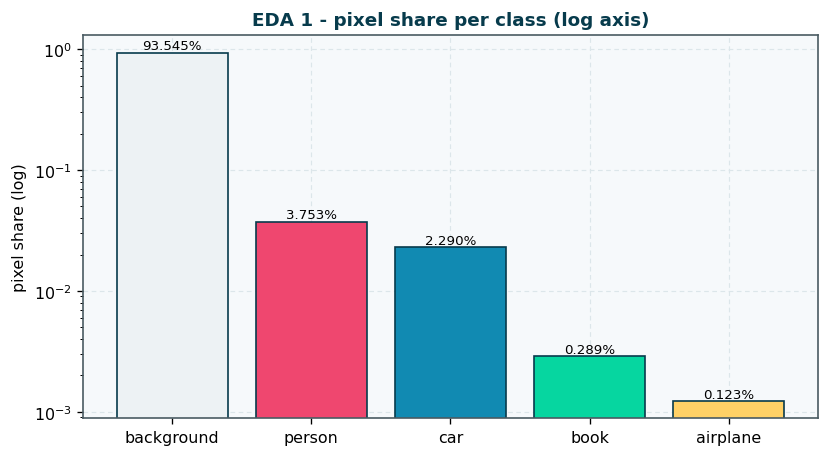

background covers 93.5% of pixels; airplane is only 0.1232%


In [18]:
# EDA 1 - pixel share per class, log axis so the rare classes are actually visible
px_share = TR_PIXELS / TR_PIXELS.sum()
fig, ax = plt.subplots(figsize=(7, 3.9))
bar_h = ax.bar(TAGS, np.maximum(px_share, 1e-6),
              color=[SWATCHES[c] / 255 for c in range(NUM_TAGS)], edgecolor="#073b4c")
ax.set_yscale("log"); ax.set_ylabel("pixel share (log)")
for r, c in zip(bar_h, range(NUM_TAGS)):
    ax.text(r.get_x() + r.get_width() / 2, r.get_height(), f"{100 * px_share[c]:.3f}%",
            ha="center", va="bottom", fontsize=8)
ax.set_title("EDA 1 - pixel share per class (log axis)")
plt.tight_layout(); plt.show()
print("background covers", f"{100*px_share[0]:.1f}%", "of pixels; airplane is only", f"{100*px_share[4]:.4f}%")

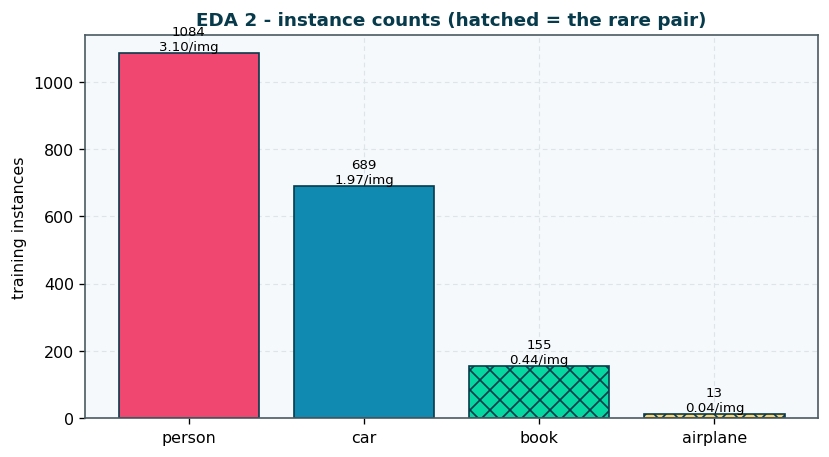

In [19]:
# EDA 2 - training instance counts, with the rare pair hatched and per-image density labelled
fig, ax = plt.subplots(figsize=(7, 3.9))
bar_h = ax.bar(train_counts.index, train_counts.values,
              color=[SWATCHES[c] / 255 for c in OBJECT_IDS], edgecolor="#073b4c")
for i, c in enumerate(OBJECT_IDS):
    if c in SCARCE_IDS:
        bar_h[i].set_hatch("xx")
for r, name in zip(bar_h, train_counts.index):
    ax.text(r.get_x() + r.get_width() / 2, r.get_height(),
            f"{int(r.get_height())}\n{per_image[name]:.2f}/img", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("training instances")
ax.set_title("EDA 2 - instance counts (hatched = the rare pair)")
plt.tight_layout(); plt.show()

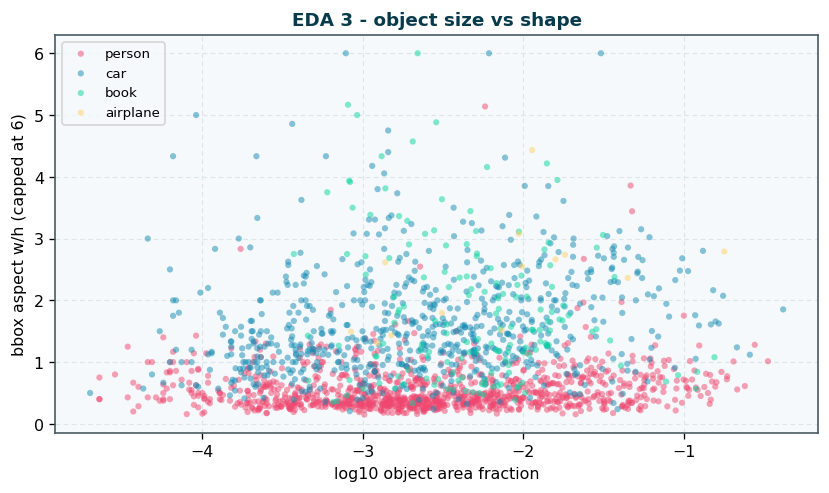

In [20]:
# EDA 3 - object size against shape. Each dot is one instance; books are tiny, airplanes are wide.
fig, ax = plt.subplots(figsize=(7, 4.2))
tr = INSTANCE_DF[INSTANCE_DF.split == "train"]
for c in OBJECT_IDS:
    sub = tr[tr.cls == TAGS[c]]
    ax.scatter(np.log10(sub["area_frac"].clip(lower=1e-6)), sub["aspect"].clip(upper=6),
               s=14, alpha=0.5, color=SWATCHES[c] / 255, label=TAGS[c], edgecolor="none")
ax.set_xlabel("log10 object area fraction"); ax.set_ylabel("bbox aspect w/h (capped at 6)")
ax.set_title("EDA 3 - object size vs shape"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

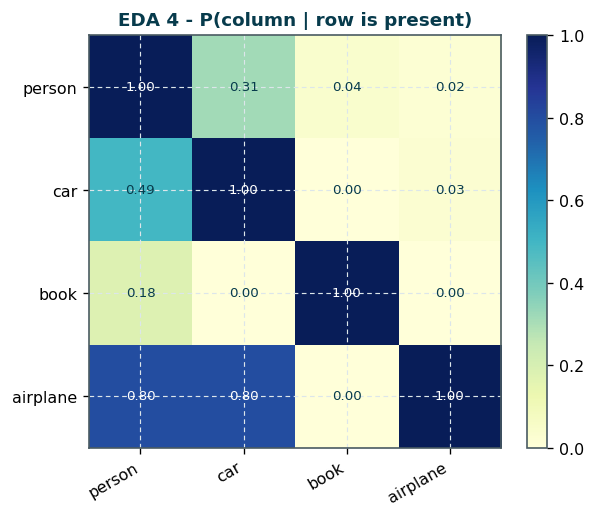

In [21]:
# EDA 4 - co-occurrence: given an image has the row class, how often does it also have the column class
presence = [{COCO_TO_ID[a["category_id"]] for a in TRAIN_ANN_MAP.get(i, [])} for i in TRAIN_FRAMES]
CO = np.zeros((len(OBJECT_IDS), len(OBJECT_IDS)))
for i, a in enumerate(OBJECT_IDS):
    holders = [p for p in presence if a in p]
    for j, b in enumerate(OBJECT_IDS):
        CO[i, j] = np.mean([b in p for p in holders]) if holders else 0.0
fig, ax = plt.subplots(figsize=(5.2, 4.4))
hmap = ax.imshow(CO, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(OBJECT_IDS))); ax.set_xticklabels(TAGS[1:], rotation=30, ha="right")
ax.set_yticks(range(len(OBJECT_IDS))); ax.set_yticklabels(TAGS[1:])
for i in range(len(OBJECT_IDS)):
    for j in range(len(OBJECT_IDS)):
        ax.text(j, i, f"{CO[i, j]:.2f}", ha="center", va="center",
                color="white" if CO[i, j] > 0.55 else "#073b4c", fontsize=8)
ax.set_title("EDA 4 - P(column | row is present)")
fig.colorbar(hmap, fraction=0.046); plt.tight_layout(); plt.show()

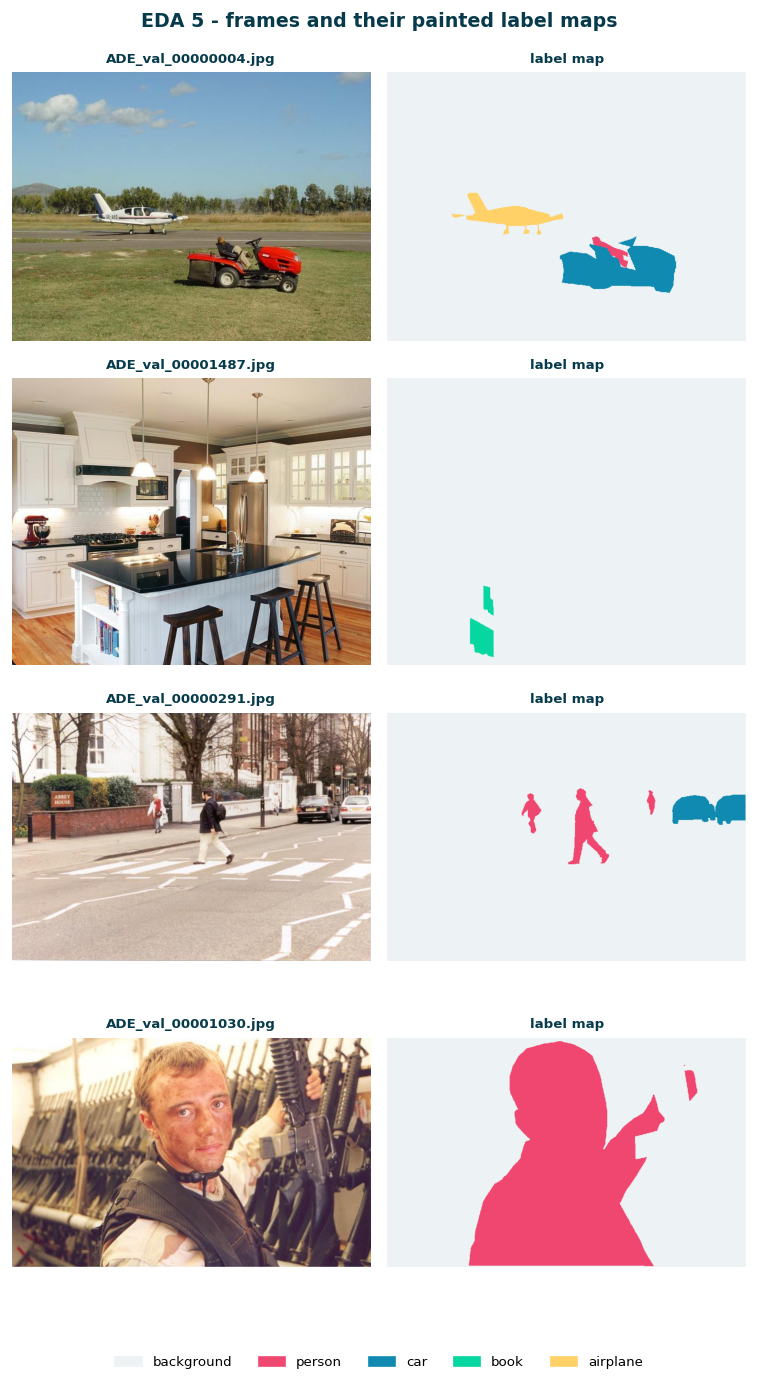

In [22]:
# EDA 5 - a small gallery: raw frame next to its colour-coded label map, one per foreground class
lock_rng()
gal_ids = []
for c in [4, 3, 2, 1]:                                # airplane, book, car, person
    owners = [iid for iid, m in TRAIN_LABELS.items() if (m == c).any()]
    if owners:
        gal_ids.append(random.choice(owners))
fig, ax = plt.subplots(len(gal_ids), 2, figsize=(6.4, 2.9 * len(gal_ids)))
for r, iid in enumerate(gal_ids):
    fn = TRAIN_FRAMES[iid]["file_name"]
    with zipfile.ZipFile(DATA_ZIP) as z:
        pic = Image.open(io.BytesIO(z.read(PIC_INDEX[("train", fn)]))).convert("RGB")
    ax[r, 0].imshow(pic); ax[r, 0].set_title(fn[:22], fontsize=8)
    ax[r, 1].imshow(SWATCHES[TRAIN_LABELS[iid]]); ax[r, 1].set_title("label map", fontsize=8)
    for a in ax[r]:
        a.axis("off")
fig.legend(handles=[Patch(color=SWATCHES[c] / 255, label=TAGS[c]) for c in range(NUM_TAGS)],
           loc="lower center", ncol=5, frameon=False, fontsize=8)
fig.suptitle("EDA 5 - frames and their painted label maps", weight="bold", color="#073b4c")
plt.tight_layout(rect=[0, 0.04, 1, 0.99]); plt.show()

## 6  Fork-safe Dataset and the per-resolution loaders

The Dataset takes a resolution argument, because that is the only knob the study changes. Images get bilinear-resized to the arm's resolution and label maps get nearest-neighbour resized to the same size (never bilinear on labels, that would invent class ids that do not exist).

The zip reader is opened lazily per process and dropped whenever the object is pickled, so each DataLoader worker opens its own. The first version of this shared one open zip across workers and died with a bad-CRC error, which is what `__getstate__` is guarding against.

In [23]:
MEAN_RGB = np.array([0.485, 0.456, 0.406], np.float32)
STD_RGB = np.array([0.229, 0.224, 0.225], np.float32)

class ResArmSet(Dataset):
    """One (image, label) pair rendered at a chosen square resolution."""
    def __init__(self, split, pairs, labels, res, train=False):
        self.zip_path = str(DATA_ZIP)
        self.split = split
        self.pairs = pairs            # list of (image_id, file_name); image_id is None for test
        self.labels = labels          # {image_id: uint8 map} or None for the unlabelled split
        self.res = res
        self.train = train
        self._zf = None
        self._owner = None

    @property
    def reader(self):
        pid = os.getpid()
        if self._zf is None or self._owner != pid:    # fresh reader the first time each process asks
            self._zf = zipfile.ZipFile(self.zip_path)
            self._owner = pid
        return self._zf

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_zf"] = None           # never pickle a live zip reader into a worker
        state["_owner"] = None
        return state

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        iid, fn = self.pairs[i]
        r = self.res
        raw = self.reader.read(PIC_INDEX[(self.split, fn)])
        pic = Image.open(io.BytesIO(raw)).convert("RGB").resize((r, r), Image.BILINEAR)
        arr = np.asarray(pic, np.float32) / 255.0
        if self.labels is not None:
            lab = Image.fromarray(self.labels[iid]).resize((r, r), Image.NEAREST)
            lab = np.asarray(lab, np.int64)
        else:
            lab = np.zeros((r, r), np.int64)
        if self.train and random.random() < 0.5:      # cheap horizontal flip, same for image and label
            arr = arr[:, ::-1, :].copy(); lab = lab[:, ::-1].copy()
        arr = (arr - MEAN_RGB) / STD_RGB
        x = torch.from_numpy(arr.transpose(2, 0, 1).copy())
        y = torch.from_numpy(lab)
        return x, y, fn

def _pairs(frames):
    return [(iid, frames[iid]["file_name"]) for iid in frames]

TEST_PAIRS = [(None, fn) for (sp, fn) in sorted(PIC_INDEX) if sp == "test"]

def _pin_worker(wid):
    s = SETUP.seed + wid
    np.random.seed(s); random.seed(s)

def make_split_loaders(res):
    tr = ResArmSet("train", _pairs(TRAIN_FRAMES), TRAIN_LABELS, res, train=True)
    va = ResArmSet("val", _pairs(VAL_FRAMES), VAL_LABELS, res, train=False)
    train_dl = DataLoader(tr, batch_size=SETUP.batch_size, shuffle=True,
                          num_workers=SETUP.num_workers, pin_memory=True, drop_last=True,
                          worker_init_fn=_pin_worker, generator=BATCH_GEN)
    val_dl = DataLoader(va, batch_size=SETUP.batch_size, shuffle=False,
                        num_workers=SETUP.num_workers, pin_memory=True,
                        worker_init_fn=_pin_worker)
    return train_dl, val_dl

_probe_tr, _ = make_split_loaders(256)
_bx, _by, _ = next(iter(_probe_tr))
print("probe batch at 256px:", tuple(_bx.shape), "| label ids present:", torch.unique(_by).tolist())
del _probe_tr, _bx, _by

probe batch at 256px: (8, 3, 256, 256) | label ids present: [0, 1, 2, 3]


## 7  The fixed network (PAN) and the fixed loss

I picked PAN because none of the usual suspects (Unet, FPN, DeepLab, MAnet, Linknet) is PAN, and its Feature Pyramid Attention block reads the deepest /32 feature map, which is exactly the part that changes when I move the resolution around. Its decoder is light so I can actually fit 512px on a T4.

For the loss I use class-weighted cross-entropy with ENet weights, `w = 1 / ln(1.02 + pixel_share)` from Paszke et al. 2016. I compute the weights once from the full-resolution masks and reuse the exact same vector for all three arms, so resolution stays the only variable in the experiment.

In [24]:
def build_pan():
    return smp.PAN(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=NUM_TAGS)

_net = build_pan()
print(f"PAN(resnet34): {sum(p.numel() for p in _net.parameters()) / 1e6:.1f}M parameters")
del _net

def enet_weights(pixel_counts):
    # rare classes get a bigger weight, but the 1.02 offset keeps it from exploding
    frac = pixel_counts / pixel_counts.sum()
    return (1.0 / np.log(1.02 + frac)).astype(np.float32)

LOSS_W = torch.from_numpy(enet_weights(TR_PIXELS))
print("ENet class weights:", {TAGS[c]: round(float(LOSS_W[c]), 2) for c in range(NUM_TAGS)})

def weighted_ce():
    return nn.CrossEntropyLoss(weight=LOSS_W.to(RUN_DEV))

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

PAN(resnet34): 21.5M parameters
ENet class weights: {'background': 1.49, 'person': 17.88, 'car': 23.81, 'book': 44.19, 'airplane': 47.6}


## 8  Metrics from a confusion matrix (per-class IoU and Dice)

In [25]:
class ScoreBook:
    """Piles up a confusion matrix, then reads out per-class IoU and Dice plus foreground means."""
    def __init__(self, n=NUM_TAGS):
        self.n = n
        self.cm = np.zeros((n, n), np.int64)

    def add_batch(self, logits, target):
        pred = logits.argmax(1).cpu().numpy().ravel()
        gt = target.cpu().numpy().ravel()
        self.cm += np.bincount(gt * self.n + pred, minlength=self.n * self.n).reshape(self.n, self.n)

    def readout(self):
        cm = self.cm.astype(np.float64)
        tp = np.diag(cm)
        fp = cm.sum(0) - tp
        fn = cm.sum(1) - tp
        iou = tp / np.maximum(tp + fp + fn, 1e-9)
        dice = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9)
        seen = [c for c in OBJECT_IDS if cm[c].sum() > 0]
        miou = float(np.mean([iou[c] for c in seen])) if seen else 0.0
        mdice = float(np.mean([dice[c] for c in seen])) if seen else 0.0
        return dict(iou=iou, dice=dice, miou=miou, mdice=mdice, cm=cm)

# quick self-test: a perfect prediction has to score foreground mIoU 1.0
_dummy = torch.randint(0, NUM_TAGS, (2, 10, 10))
_sb = ScoreBook()
_sb.add_batch(F.one_hot(_dummy, NUM_TAGS).permute(0, 3, 1, 2).float() * 25, _dummy)
print("sanity check - perfect prediction gives fg mIoU:", round(_sb.readout()["miou"], 3))

sanity check - perfect prediction gives fg mIoU: 1.0


## 9  Training engine

Every arm evaluates at its own resolution, so the confusion matrix for the 512 arm is built from 512px predictions against 512px label maps, and likewise for the others. Mixed precision is on so the 512 arm fits, and I early-stop on validation foreground mIoU.

In [26]:
@torch.inference_mode()
def gauge(model, loader):
    model.eval()
    book = ScoreBook()
    for x, y, _ in loader:
        with torch.autocast(RUN_DEV.type, enabled=(RUN_DEV.type == "cuda")):
            logits = model(x.to(RUN_DEV))
        book.add_batch(logits.float(), y.to(RUN_DEV))
    return book.readout()

def train_at_res(res):
    lock_rng(SETUP.seed)                              # identical starting point for every arm
    if RUN_DEV.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    model = build_pan().to(RUN_DEV)
    crit = weighted_ce()
    train_dl, val_dl = make_split_loaders(res)
    opt = torch.optim.AdamW(model.parameters(), lr=SETUP.lr, weight_decay=SETUP.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SETUP.epochs)
    scaler = torch.amp.GradScaler(RUN_DEV.type, enabled=(RUN_DEV.type == "cuda"))
    ckpt = os.path.join(SETUP.out_dir, f"pan_{res}.pt")
    best = {"miou": -1.0}; wait = 0; hist = []
    clock = time.time()
    for ep in range(1, SETUP.epochs + 1):
        model.train(); running = 0.0
        for x, y, _ in train_dl:
            x, y = x.to(RUN_DEV), y.to(RUN_DEV)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(RUN_DEV.type, enabled=(RUN_DEV.type == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running += loss.item() * x.size(0)
        sched.step()
        sc = gauge(model, val_dl)
        sc["epoch"] = ep; sc["train_loss"] = running / len(train_dl.dataset)
        hist.append({k: sc[k] for k in ("epoch", "train_loss", "miou", "mdice")})
        if sc["miou"] > best["miou"]:
            best = dict(sc); torch.save(model.state_dict(), ckpt); wait = 0
        else:
            wait += 1
        print(f"[{res}px] ep{ep:02d} loss {sc['train_loss']:.3f} | val mIoU {sc['miou']:.3f} "
              f"(best {best['miou']:.3f}) | " +
              " ".join(f"{TAGS[c][:4]} {sc['iou'][c]:.2f}" for c in OBJECT_IDS))
        if wait >= SETUP.patience:
            print(f"[{res}px] early stop at epoch {ep}")
            break
    secs = time.time() - clock
    vram = torch.cuda.max_memory_allocated() / 1e9 if RUN_DEV.type == "cuda" else 0.0
    print(f"[{res}px] finished in {secs/60:.1f} min | peak VRAM {vram:.2f} GB")
    return dict(res=res, best=best, ckpt=ckpt, hist=pd.DataFrame(hist), secs=secs, vram_gb=vram)

## 10  Train the three resolution arms

Same network, same loss, same optimiser and schedule. The only difference between these three cells is the number I pass in.

In [27]:
SWEEP = {}
SWEEP[256] = train_at_res(256)

[256px] ep01 loss 1.490 | val mIoU 0.102 (best 0.102) | pers 0.24 car 0.15 book 0.02 airp 0.00
[256px] ep02 loss 0.524 | val mIoU 0.152 (best 0.152) | pers 0.32 car 0.26 book 0.03 airp 0.00
[256px] ep03 loss 0.490 | val mIoU 0.223 (best 0.223) | pers 0.38 car 0.43 book 0.07 airp 0.02
[256px] ep04 loss 0.304 | val mIoU 0.245 (best 0.245) | pers 0.35 car 0.45 book 0.14 airp 0.04
[256px] ep05 loss 0.237 | val mIoU 0.266 (best 0.266) | pers 0.43 car 0.45 book 0.11 airp 0.07
[256px] ep06 loss 0.200 | val mIoU 0.246 (best 0.266) | pers 0.41 car 0.38 book 0.14 airp 0.05
[256px] ep07 loss 0.173 | val mIoU 0.272 (best 0.272) | pers 0.44 car 0.43 book 0.15 airp 0.06
[256px] ep08 loss 0.159 | val mIoU 0.265 (best 0.272) | pers 0.46 car 0.49 book 0.09 airp 0.03
[256px] ep09 loss 0.149 | val mIoU 0.268 (best 0.272) | pers 0.42 car 0.47 book 0.17 airp 0.02
[256px] ep10 loss 0.136 | val mIoU 0.285 (best 0.285) | pers 0.49 car 0.50 book 0.14 airp 0.00
[256px] ep11 loss 0.129 | val mIoU 0.311 (best 0.3

In [28]:
SWEEP[384] = train_at_res(384)

[384px] ep01 loss 1.374 | val mIoU 0.144 (best 0.144) | pers 0.30 car 0.20 book 0.07 airp 0.01
[384px] ep02 loss 0.441 | val mIoU 0.138 (best 0.144) | pers 0.28 car 0.25 book 0.02 airp 0.00
[384px] ep03 loss 0.346 | val mIoU 0.183 (best 0.183) | pers 0.31 car 0.29 book 0.09 airp 0.04
[384px] ep04 loss 0.284 | val mIoU 0.217 (best 0.217) | pers 0.42 car 0.34 book 0.08 airp 0.03
[384px] ep05 loss 0.201 | val mIoU 0.249 (best 0.249) | pers 0.36 car 0.49 book 0.11 airp 0.03
[384px] ep06 loss 0.169 | val mIoU 0.283 (best 0.283) | pers 0.47 car 0.52 book 0.14 airp 0.00
[384px] ep07 loss 0.151 | val mIoU 0.301 (best 0.301) | pers 0.44 car 0.55 book 0.18 airp 0.03
[384px] ep08 loss 0.139 | val mIoU 0.217 (best 0.301) | pers 0.51 car 0.23 book 0.13 airp 0.00
[384px] ep09 loss 0.145 | val mIoU 0.300 (best 0.301) | pers 0.49 car 0.56 book 0.11 airp 0.05
[384px] ep10 loss 0.126 | val mIoU 0.293 (best 0.301) | pers 0.50 car 0.46 book 0.15 airp 0.06
[384px] ep11 loss 0.109 | val mIoU 0.305 (best 0.3

In [29]:
SWEEP[512] = train_at_res(512)

[512px] ep01 loss 1.311 | val mIoU 0.147 (best 0.147) | pers 0.27 car 0.25 book 0.04 airp 0.02
[512px] ep02 loss 0.417 | val mIoU 0.234 (best 0.234) | pers 0.35 car 0.51 book 0.03 airp 0.05
[512px] ep03 loss 0.323 | val mIoU 0.248 (best 0.248) | pers 0.36 car 0.52 book 0.07 airp 0.04
[512px] ep04 loss 0.251 | val mIoU 0.286 (best 0.286) | pers 0.50 car 0.47 book 0.11 airp 0.06
[512px] ep05 loss 0.180 | val mIoU 0.297 (best 0.297) | pers 0.45 car 0.57 book 0.12 airp 0.06
[512px] ep06 loss 0.163 | val mIoU 0.265 (best 0.297) | pers 0.39 car 0.47 book 0.17 airp 0.03
[512px] ep07 loss 0.134 | val mIoU 0.301 (best 0.301) | pers 0.39 car 0.56 book 0.20 airp 0.05
[512px] ep08 loss 0.120 | val mIoU 0.328 (best 0.328) | pers 0.50 car 0.56 book 0.17 airp 0.09
[512px] ep09 loss 0.117 | val mIoU 0.279 (best 0.328) | pers 0.56 car 0.39 book 0.14 airp 0.03
[512px] ep10 loss 0.157 | val mIoU 0.310 (best 0.328) | pers 0.44 car 0.59 book 0.12 airp 0.10
[512px] ep11 loss 0.116 | val mIoU 0.307 (best 0.3

## 11  Off-the-shelf reference: COCO LR-ASPP MobileNetV3

A pretrained LR-ASPP with both classifier heads re-pointed at 5 classes and a short fine-tune. It is thematically the same question from the other side: how does a model I did not design behave as I hand it bigger and bigger images. I fine-tune it once at 384px and then evaluate it at all three resolutions.

In [30]:
from torchvision.models.segmentation import (
    lraspp_mobilenet_v3_large, LRASPP_MobileNet_V3_Large_Weights)

class OffTheShelfLRASPP(nn.Module):
    """COCO-pretrained LR-ASPP MobileNetV3 with both little heads re-pointed at our classes."""
    def __init__(self, n):
        super().__init__()
        net = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.DEFAULT)
        net.classifier.low_classifier = nn.Conv2d(net.classifier.low_classifier.in_channels, n, 1)
        net.classifier.high_classifier = nn.Conv2d(net.classifier.high_classifier.in_channels, n, 1)
        self.net = net

    def forward(self, x):
        return self.net(x)["out"]

def finetune_reference(res=384):
    lock_rng(SETUP.seed)
    model = OffTheShelfLRASPP(NUM_TAGS).to(RUN_DEV)
    crit = weighted_ce()
    train_dl, val_dl = make_split_loaders(res)
    opt = torch.optim.AdamW(model.parameters(), lr=SETUP.ref_lr, weight_decay=SETUP.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SETUP.ref_epochs)
    scaler = torch.amp.GradScaler(RUN_DEV.type, enabled=(RUN_DEV.type == "cuda"))
    ckpt = os.path.join(SETUP.out_dir, "reference_lraspp.pt")
    best = {"miou": -1.0}
    for ep in range(1, SETUP.ref_epochs + 1):
        model.train()
        for x, y, _ in train_dl:
            x, y = x.to(RUN_DEV), y.to(RUN_DEV)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(RUN_DEV.type, enabled=(RUN_DEV.type == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        sc = gauge(model, val_dl)
        if sc["miou"] > best["miou"]:
            best = dict(sc); torch.save(model.state_dict(), ckpt)
        print(f"[reference@{res}] ep{ep:02d} val mIoU {sc['miou']:.3f} (best {best['miou']:.3f})")
    model.load_state_dict(torch.load(ckpt, map_location=RUN_DEV))
    return model, ckpt

REF_NET, REF_CKPT = finetune_reference(res=384)

Downloading: "https://download.pytorch.org/models/lraspp_mobilenet_v3_large-d234d4ea.pth" to /root/.cache/torch/hub/checkpoints/lraspp_mobilenet_v3_large-d234d4ea.pth


100%|██████████| 12.5M/12.5M [00:00<00:00, 58.8MB/s]


[reference@384] ep01 val mIoU 0.130 (best 0.130)
[reference@384] ep02 val mIoU 0.179 (best 0.179)
[reference@384] ep03 val mIoU 0.221 (best 0.221)
[reference@384] ep04 val mIoU 0.267 (best 0.267)
[reference@384] ep05 val mIoU 0.359 (best 0.359)
[reference@384] ep06 val mIoU 0.377 (best 0.377)
[reference@384] ep07 val mIoU 0.381 (best 0.381)
[reference@384] ep08 val mIoU 0.379 (best 0.381)


In [31]:
# now sweep the SAME fine-tuned reference across the three eval resolutions
REF_SCORES = {}
for r in SETUP.resolutions:
    _, val_dl = make_split_loaders(r)
    REF_SCORES[r] = gauge(REF_NET, val_dl)
    print(f"reference evaluated at {r}px -> mIoU {REF_SCORES[r]['miou']:.3f} | "
          f"mDice {REF_SCORES[r]['mdice']:.3f}")

reference evaluated at 256px -> mIoU 0.347 | mDice 0.504
reference evaluated at 384px -> mIoU 0.381 | mDice 0.541
reference evaluated at 512px -> mIoU 0.390 | mDice 0.548


## 12  Headline table: per-class and mean IoU + Dice

The three PAN arms plus the reference (shown at its 384px fine-tune resolution). Everything here is measured on the validation split.

In [32]:
def row_from_scores(name, sc):
    row = {"model": name, "mIoU": sc["miou"], "mDice": sc["mdice"]}
    for c in OBJECT_IDS:
        row[f"IoU_{TAGS[c]}"] = sc["iou"][c]
        row[f"Dice_{TAGS[c]}"] = sc["dice"][c]
    return row

table_rows = [row_from_scores(f"PAN@{r}", SWEEP[r]["best"]) for r in SETUP.resolutions]
table_rows.append(row_from_scores("reference@384", REF_SCORES[384]))
HEADLINE = pd.DataFrame(table_rows).set_index("model")
HEADLINE.to_csv(os.path.join(SETUP.out_dir, "headline_scores.csv"))
print("Validation per-class IoU / Dice (best epoch per PAN arm; reference at 384px):\n")
print(HEADLINE.round(3).to_string())

lo = SWEEP[256]["best"]["iou"]; hi = SWEEP[512]["best"]["iou"]
print("\nDoes 512px rescue the rare pair versus 256px?")
for c in SCARCE_IDS:
    print(f"  {TAGS[c]:9s} IoU 256 -> 512 : {lo[c]:.3f} -> {hi[c]:.3f}  ({hi[c]-lo[c]:+.3f})")

Validation per-class IoU / Dice (best epoch per PAN arm; reference at 384px):

                mIoU  mDice  IoU_person  Dice_person  IoU_car  Dice_car  IoU_book  Dice_book  IoU_airplane  Dice_airplane
model                                                                                                                    
PAN@256        0.319  0.444       0.497        0.664    0.543     0.704     0.182      0.308         0.052          0.100
PAN@384        0.328  0.433       0.565        0.722    0.601     0.751     0.141      0.247         0.007          0.014
PAN@512        0.344  0.458       0.566        0.723    0.595     0.746     0.201      0.334         0.015          0.029
reference@384  0.381  0.541       0.498        0.665    0.453     0.623     0.190      0.320         0.384          0.555

Does 512px rescue the rare pair versus 256px?
  book      IoU 256 -> 512 : 0.182 -> 0.201  (+0.019)
  airplane  IoU 256 -> 512 : 0.052 -> 0.015  (-0.038)


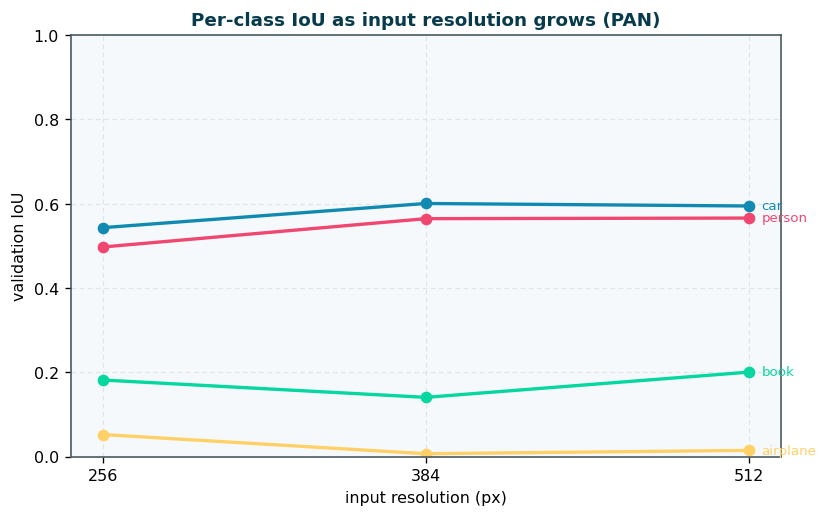

In [33]:
# Figure - per-class IoU as the input resolution grows (the headline question, one line per class)
fig, ax = plt.subplots(figsize=(7, 4.4))
res_grid = list(SETUP.resolutions)
for c in OBJECT_IDS:
    ys = [SWEEP[r]["best"]["iou"][c] for r in res_grid]
    ax.plot(res_grid, ys, marker="o", linewidth=2, color=SWATCHES[c] / 255, label=TAGS[c])
    ax.text(res_grid[-1] + 5, ys[-1], TAGS[c], va="center", fontsize=8, color=SWATCHES[c] / 255)
ax.set_xticks(res_grid); ax.set_xlabel("input resolution (px)"); ax.set_ylabel("validation IoU")
ax.set_ylim(0, 1); ax.set_title("Per-class IoU as input resolution grows (PAN)")
plt.tight_layout(); plt.show()

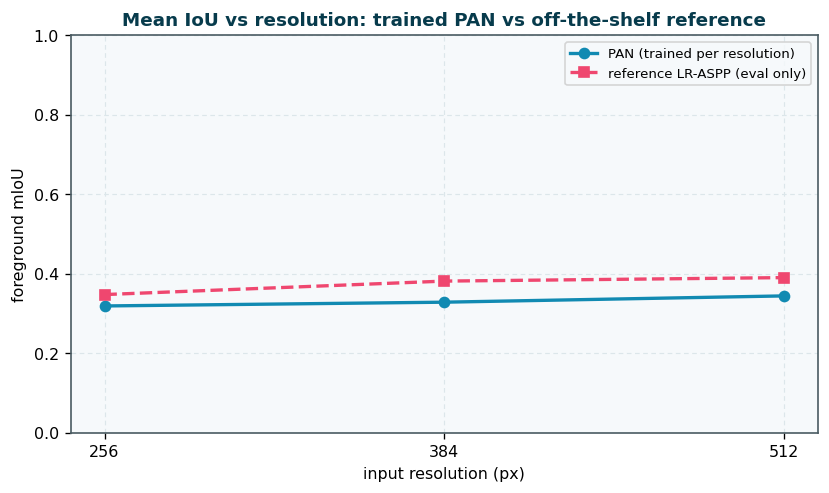

In [34]:
# Figure - mean IoU vs resolution: my trained PAN against the off-the-shelf reference
fig, ax = plt.subplots(figsize=(7, 4.2))
res_grid = list(SETUP.resolutions)
ax.plot(res_grid, [SWEEP[r]["best"]["miou"] for r in res_grid], marker="o", linewidth=2,
        color=SWATCHES[2] / 255, label="PAN (trained per resolution)")
ax.plot(res_grid, [REF_SCORES[r]["miou"] for r in res_grid], marker="s", linewidth=2, linestyle="--",
        color=SWATCHES[1] / 255, label="reference LR-ASPP (eval only)")
ax.set_xticks(res_grid); ax.set_xlabel("input resolution (px)"); ax.set_ylabel("foreground mIoU")
ax.set_ylim(0, 1); ax.set_title("Mean IoU vs resolution: trained PAN vs off-the-shelf reference")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

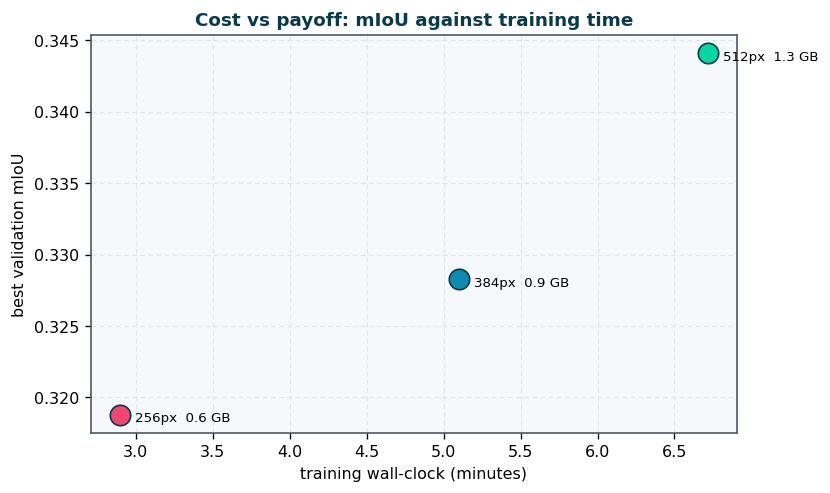

In [35]:
# Figure - is the extra compute worth it? best mIoU against training wall-clock, VRAM annotated
res_hue = {256: SWATCHES[1] / 255, 384: SWATCHES[2] / 255, 512: SWATCHES[3] / 255}
fig, ax = plt.subplots(figsize=(7, 4.2))
for r in SETUP.resolutions:
    mins = SWEEP[r]["secs"] / 60
    miou = SWEEP[r]["best"]["miou"]
    ax.scatter(mins, miou, s=150, color=res_hue[r], edgecolor="#073b4c", zorder=3)
    ax.annotate(f"{r}px  {SWEEP[r]['vram_gb']:.1f} GB", (mins, miou),
                textcoords="offset points", xytext=(9, -4), fontsize=8)
ax.set_xlabel("training wall-clock (minutes)"); ax.set_ylabel("best validation mIoU")
ax.set_title("Cost vs payoff: mIoU against training time")
plt.tight_layout(); plt.show()

## 13  Validation panels for the best PAN arm

best PAN arm: 512px | val mIoU 0.344


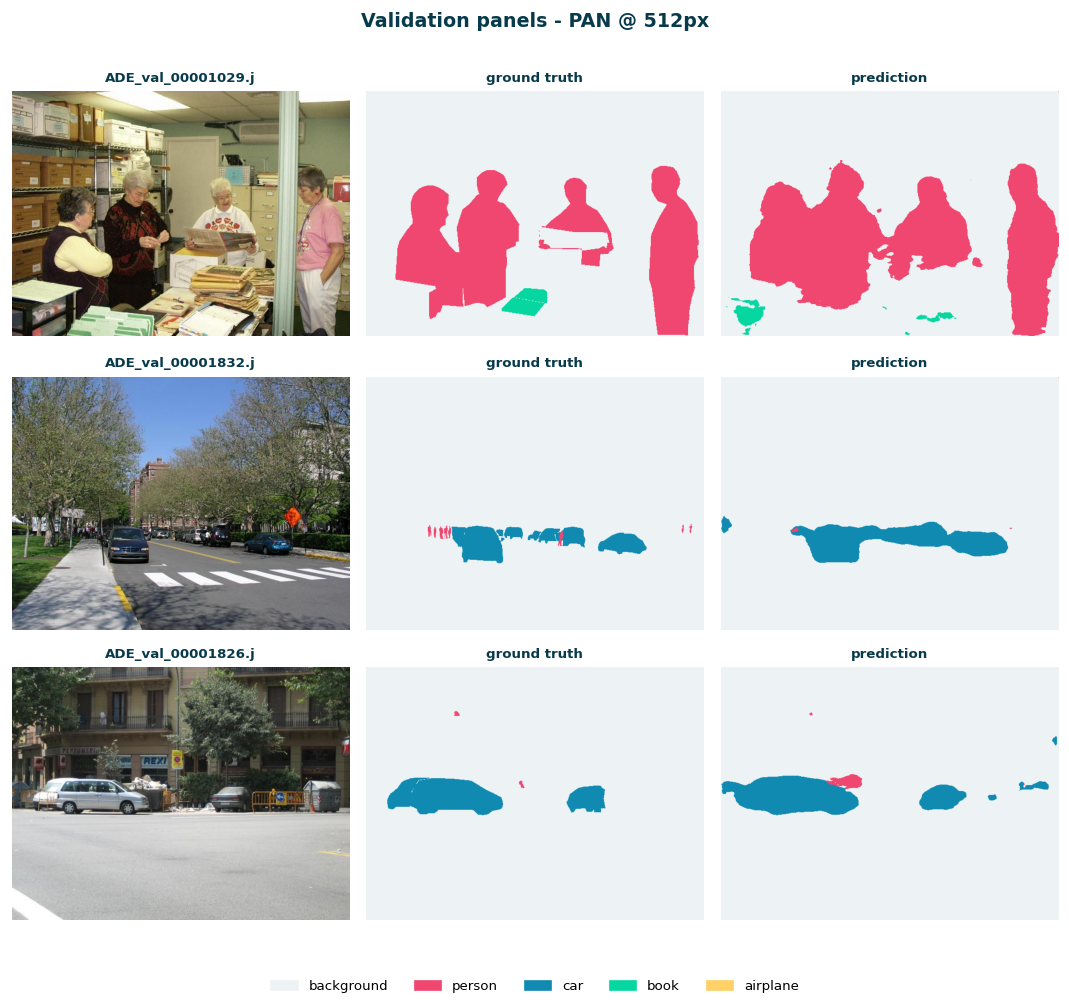

In [36]:
best_res = max(SETUP.resolutions, key=lambda r: SWEEP[r]["best"]["miou"])
STAR = build_pan().to(RUN_DEV)
STAR.load_state_dict(torch.load(SWEEP[best_res]["ckpt"], map_location=RUN_DEV))
STAR.eval()
print("best PAN arm:", f"{best_res}px", "| val mIoU", round(SWEEP[best_res]["best"]["miou"], 3))

@torch.inference_mode()
def label_one(model, pil_img, res):
    arr = np.asarray(pil_img.resize((res, res), Image.BILINEAR), np.float32) / 255.0
    arr = (arr - MEAN_RGB) / STD_RGB
    x = torch.from_numpy(arr.transpose(2, 0, 1).copy())[None].to(RUN_DEV)
    logits = model(x)
    up = F.interpolate(logits, size=pil_img.size[::-1], mode="bilinear", align_corners=False)
    return up.argmax(1)[0].cpu().numpy().astype(np.uint8)

def show_val_panels(model, res, n=3):
    lock_rng()
    have_fg = [iid for iid in VAL_FRAMES if any((VAL_LABELS[iid] == c).any() for c in OBJECT_IDS)]
    chosen = random.sample(have_fg, n)
    fig, ax = plt.subplots(n, 3, figsize=(9, 2.8 * n))
    for r, iid in enumerate(chosen):
        fn = VAL_FRAMES[iid]["file_name"]
        with zipfile.ZipFile(DATA_ZIP) as z:
            pic = Image.open(io.BytesIO(z.read(PIC_INDEX[("val", fn)]))).convert("RGB")
        pred = label_one(model, pic, res)
        ax[r, 0].imshow(pic); ax[r, 0].set_title(fn[:18], fontsize=8)
        ax[r, 1].imshow(SWATCHES[VAL_LABELS[iid]]); ax[r, 1].set_title("ground truth", fontsize=8)
        ax[r, 2].imshow(SWATCHES[pred]); ax[r, 2].set_title("prediction", fontsize=8)
        for a in ax[r]:
            a.axis("off")
    fig.legend(handles=[Patch(color=SWATCHES[c] / 255, label=TAGS[c]) for c in range(NUM_TAGS)],
               loc="lower center", ncol=5, frameon=False, fontsize=8)
    fig.suptitle(f"Validation panels - PAN @ {res}px", weight="bold", color="#073b4c")
    plt.tight_layout(rect=[0, 0.04, 1, 0.98]); plt.show()

show_val_panels(STAR, best_res, n=3)

## 14  Test panels on the unlabelled images

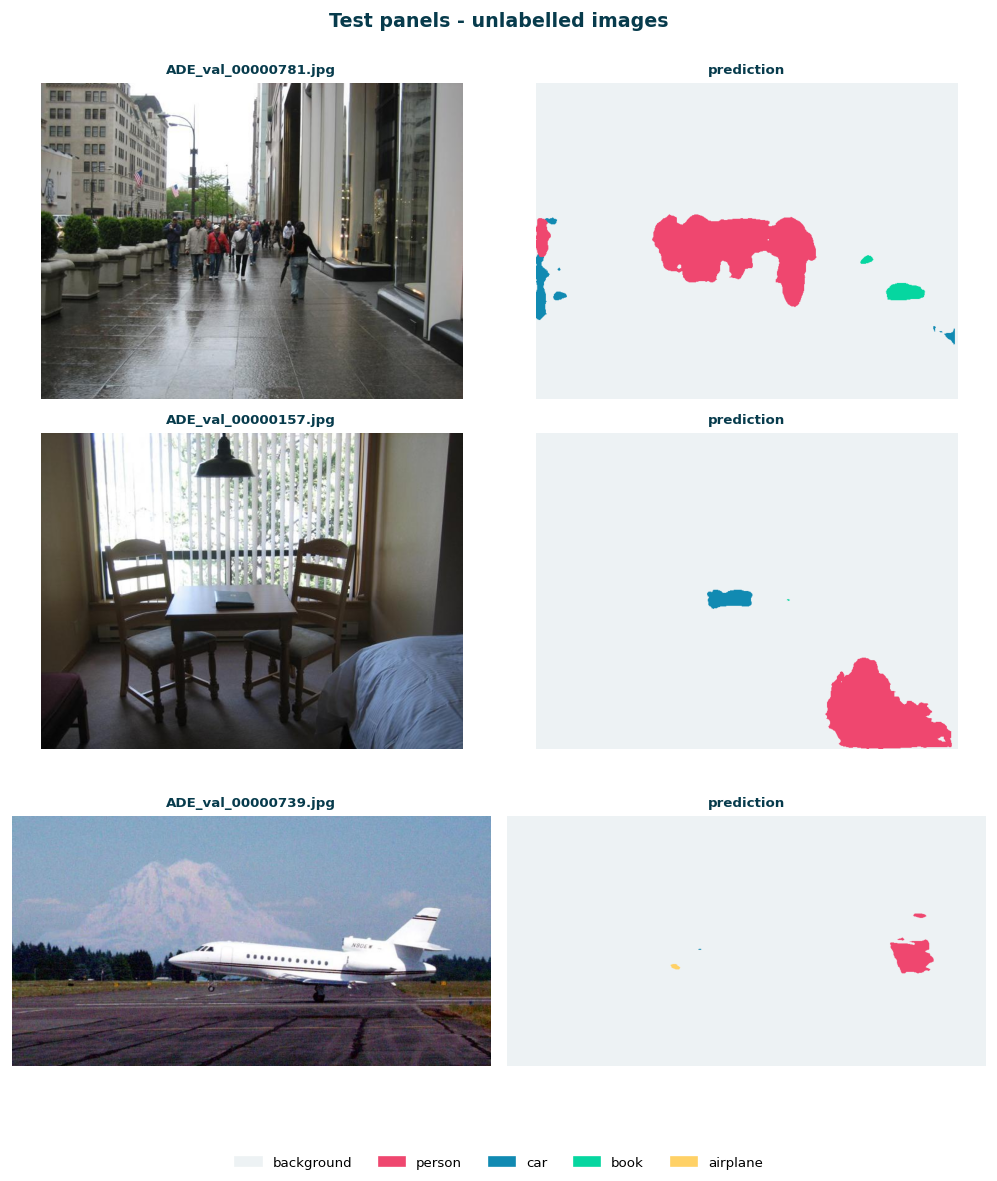

The test split has no labels, so these are eyeball-only. Every number in the tables above is from val.


In [37]:
@torch.inference_mode()
def show_test_predictions(model, res, n=3):
    ranked = []
    for _, fn in TEST_PAIRS:
        with zipfile.ZipFile(DATA_ZIP) as z:
            pic = Image.open(io.BytesIO(z.read(PIC_INDEX[("test", fn)]))).convert("RGB")
        pred = label_one(model, pic, res)
        ranked.append((len(set(np.unique(pred)) - {0}), int((pred > 0).sum()), fn, pic, pred))
    ranked.sort(key=lambda t: (-t[0], -t[1]))         # show the busiest predictions first
    show = ranked[:n]
    fig, ax = plt.subplots(n, 2, figsize=(8.4, 3.3 * n))
    for r, (_, _, fn, pic, pred) in enumerate(show):
        ax[r, 0].imshow(pic); ax[r, 0].set_title(fn[:20], fontsize=8); ax[r, 0].axis("off")
        ax[r, 1].imshow(SWATCHES[pred]); ax[r, 1].set_title("prediction", fontsize=8); ax[r, 1].axis("off")
    fig.legend(handles=[Patch(color=SWATCHES[c] / 255, label=TAGS[c]) for c in range(NUM_TAGS)],
               loc="lower center", ncol=5, frameon=False, fontsize=8)
    fig.suptitle("Test panels - unlabelled images", weight="bold", color="#073b4c")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

show_test_predictions(STAR, best_res, n=3)
print("The test split has no labels, so these are eyeball-only. Every number in the tables above is from val.")